# Monte Carlo Simulation of Stock Prices as Geometric Brownian Motion

We simulate several possible stock price paths using the standard Geometric Brownian Motion model, then analyze the distribution of final stock prices.

The goal of this project is to built intuition with the fundementals of quantitative finance, and provide a foundation for future work in my portfolio.

## Model Details

We assume that stock prices follow Geometric Brownian Motion, as defined by the stochastic differential equation:

$dS_t = \mu S_t dt + \sigma S_t dW_t$

where:
- $S_t$ is the stock price
- $\mu$ is the expected return ("drift")
- $\sigma$ is the volatility
- $dW_t$ is a "brownian motion increment" known as a Wiener process

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

# Note the location of the figures folder
PROJECT_ROOT = Path().resolve().parent
FIGURES = PROJECT_ROOT / "figures"

# Set the random seed for reproducability
np.random.seed(0)

# Initial stock price
S0 = 1000

# Expected annual return ("drift")
mu = 0.08

# Volatility
sigma = 0.2

# Number of years to simulate
years = 3

# Number of trading days in the year
trading_days_per_year = 251

# Number of trials
trials = 10000

# Preparing some constants and storage matrices
trading_days = int(np.round(years * trading_days_per_year))
dt = 1 / trading_days_per_year
prices = np.zeros((trading_days + 1, trials))
prices[0] = S0

## Simulation

We can solve the stochastic differential equation equation for the final price in terms of the Wiener process increments:

$S_t = S_{t - \Delta t} \exp((\mu - \frac{1}{2}\sigma^2) dt + \sigma dW_t)$

We can use this analytical solution to calculate the stock trajectory and final price over several simulations.

In [2]:
for t in range(1, trading_days + 1):
    # Create the Wiener process
    dWt = np.sqrt(dt) * np.random.standard_normal(trials)
    # Update prices using the solution to the stochastic differential equation
    prices[t] = prices[t - 1] * np.exp((mu - 0.5 * sigma**2) * dt + sigma * dWt)

## Terminal Price Analysis

After performing a large number of simulations, we can do data analysis on the final prices to get an idea for what returns are expected from our investment. I've chosen to print a number of percentiles of interest, as well as the overall average.

In [3]:
# Isolate the final prices
final_prices = prices[-1]

# Average final price
mean = np.mean(final_prices)

# Create a pandas dataframe to store final prices
df = pd.DataFrame({"final_price": final_prices})

# Compute percentiles of the final prices
percentiles = df['final_price'].quantile([0.01, 0.05, 0.1, 0.5, 0.9, 0.95, 0.99])

# Format and label the dataframe
result = percentiles.reset_index()
result.columns = ['Percentile', 'Final Price']
result['Final Price'] = result['Final Price'].round(2)
result['Percentile'] = (result['Percentile'] * 100).astype(int).astype(str) + '%'

print(result.to_string(index=False))
print()
print(f"Average Final Price: {mean: .2f}")

Percentile  Final Price
        1%       532.84
        5%       680.90
       10%       767.86
       50%      1201.00
       90%      1878.95
       95%      2152.53
       99%      2705.11

Average Final Price:  1276.84


## Visualization of Simulated Paths

The plot below shows the first 10 simulated stock price paths, where each line represents a possible trajectory of the stock price.

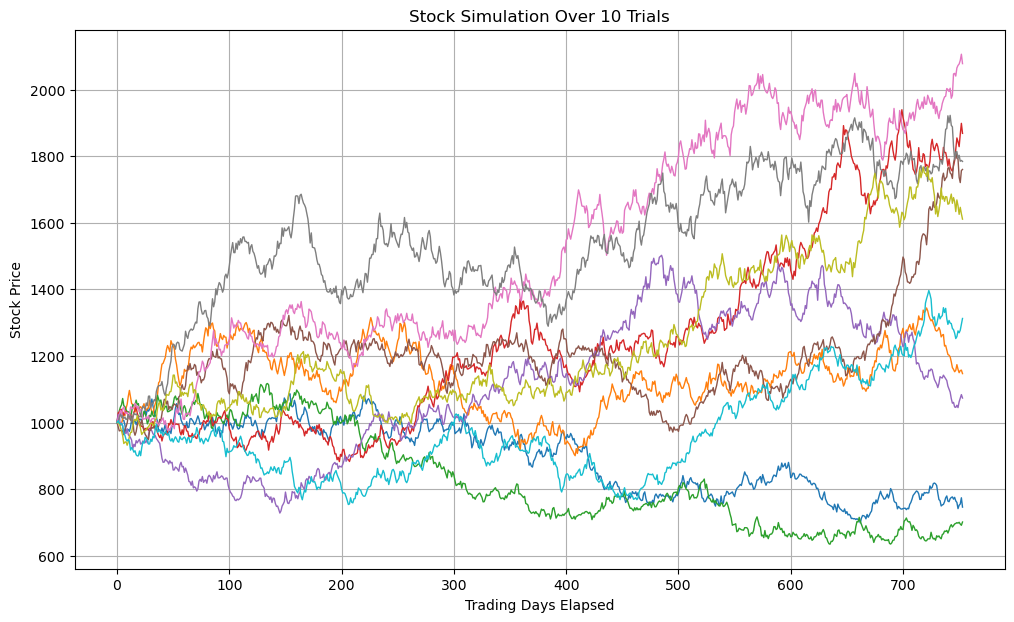

In [4]:
plt.figure(figsize=(12, 7))
plt.tight_layout()

# Plot the desired number of trials
trials_to_plot = 10
for i in range(trials_to_plot):
    plt.plot(prices[:, i], linewidth=1)

plt.title(f"Stock Simulation Over {trials_to_plot} Trials")
plt.xlabel("Trading Days Elapsed")
plt.ylabel("Stock Price")
plt.grid(True)

plt.savefig(FIGURES / "sample_paths.png", dpi=300, bbox_inches="tight")
plt.show()